# Práctica 03. Análisis Estadistico de señales

**Estudiante:** Juliana Sarmiento Arciniegas y Valentina Restrepo Cardona

## Resumen

En esta práctica se realiza un análisis estadístico en el dominio del tiempo de una señal de electrocardiograma (ECG), a partir del archivo signals.mat, el cual contiene el registro tal cual se adquirió (ECG_asRecording) y su versión filtrada (ECG_filtered), muestreadas a 1024 Hz durante 30 segundos.

Primero se implementa una función propia para calcular el valor cuadrático medio (RMS) de una señal, y se construye el vector de tiempo correspondiente al registro. Luego se comparan gráficamente la señal original y la filtrada, con el fin de identificar el efecto del filtro aplicado y las frecuencias de interés propias del ECG.

A continuación, se extrae un ciclo cardiaco de la señal original y de la filtrada, calculando para cada uno el promedio, el valor RMS, la varianza y la desviación estándar, y se comparan los resultados obtenidos entre ambas versiones de la señal.

Posteriormente, se extraen 15 ciclos cardiacos de la señal filtrada, calculando el promedio y la varianza de cada uno, con el fin de evaluar gráfica y estadísticamente si la señal puede considerarse estacionaria. Esta evaluación se refuerza mediante comparaciones entre pares de ciclos usando pruebas de hipótesis (verificando los supuestos de normalidad con Shapiro-Wilk y homocedasticidad con Levene, y aplicando la prueba t de Student o, en su defecto, la prueba no paramétrica U de Mann-Whitney), y finalmente mediante una prueba formal de estacionariedad de Dickey-Fuller aplicada sobre la señal completa.

 Funciones en Python:

*   **mean:** Calcula el promedio de un conjunto de datos (np.mean())
*   **var:** Calcula la varianza de un conjunto de datos, es decir mide cuánto se dispersan los datos respecto a la media.
*   **std:** Calcula la desviación estandar (raiz cuadrada de la varianza) y arroja valores más faciles de interpretar que la varianza

In [17]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks #ayudará más adelnate a buscar picos de señales
import pandas as pd
from scipy.stats import shapiro #Prueba de Shapiro
from scipy.stats import levene #Prueba de homocedasticidad
from scipy.stats import mannwhitneyu #Prueba de Mann Whitney U
from statsmodels.tsa.stattools import adfuller #Prueba de Augmented Dickey-Fuller

## Exportar los datos de interes para ECG

In [2]:
# Cargar archivo .mat
mat = sio.loadmat("signals.mat")

# Ver qué variables contiene para saber cuales exportar
print(mat.keys())

#verificar el tamaño del arreglo
raw = mat['ECG_asRecording']
print(raw.shape)

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])
(1, 30720)


Se hará uso de la funcion np.squeeze ya que esta permite pasar de un vector 2D, como se observa en el tamaño del vector ECG_asRecording, a un arreglo plano de una dimensión. Esto es importante para realizar operaciones matemáticas a lo largo del informe.

In [3]:
fs = float(np.squeeze(mat['Fs']))                    # frecuencia de muestreo
ecg_original = np.squeeze(mat['ECG_asRecording'])    # senal original, tal cual se registro
ecg_filtrada = np.squeeze(mat['ECG_filtered'])       # senal filtrada

print("Frecuencia de muestreo:", fs, "Hz")
print("Tamano ECG cruda:", ecg_original.shape)
print("Tamano ECG filtrada:", ecg_filtrada.shape)

Frecuencia de muestreo: 1024.0 Hz
Tamano ECG cruda: (30720,)
Tamano ECG filtrada: (30720,)


Ya teniendo un tamaño de (30720,) es más fácil continuar con las operaciones a lo largo del taller.

## Creación de la funcion RMS

### Valor cuadrático medio (RMS)

$$x_{RMS} = \left[\frac{1}{N}\sum_{i=1}^{N} x(i)^2\right]^{1/2}$$

In [4]:
def rms(x):
    x = np.asarray(x, dtype=float)   # asarray -> asegura que la entrada sea un arreglo de numpy
    return np.sqrt(np.mean(x**2))

# prueba rapida con una senoidal de amplitud conocida (RMS teorico = A/sqrt(2))
t_prueba = np.linspace(0, 1, 1000, endpoint=False)
seno_prueba = 5*np.sin(2*np.pi*10*t_prueba)
print("RMS teorico:  ", 5/np.sqrt(2))
print("RMS calculado:", rms(seno_prueba))

RMS teorico:   3.5355339059327373
RMS calculado: 3.5355339059327378


## Tiempo de duración de las señales

In [5]:
muestras_original = len(ecg_original)#muestras del vector original
muestras_filtrada = len(ecg_filtrada)#muestras del vector filtrado

#calcular el tiempo
tiempo_original = muestras_original/fs # tiempo total = N * (1/fs)
tiempo_filtrado = muestras_filtrada/fs
print("Duracion senal original :", tiempo_original, "s")
print("Duracion senal filtrada :", tiempo_filtrado, "s")

# vector de tiempo (comun a ambas senales, mismo numero de muestras)
tiempo = np.arange(muestras_filtrada)/fs #convertir a un arreglo numpy
print("Vector de tiempo (primeras 5 muestras):", tiempo[:5])

Duracion senal original : 30.0 s
Duracion senal filtrada : 30.0 s
Vector de tiempo (primeras 5 muestras): [0.         0.00097656 0.00195312 0.00292969 0.00390625]


## Comparativa entre señal filtrada y sin filtrar

Se realiza un recorte en la señal para visualizar solo el comportamiento de las señales en los dos primeros segundos.

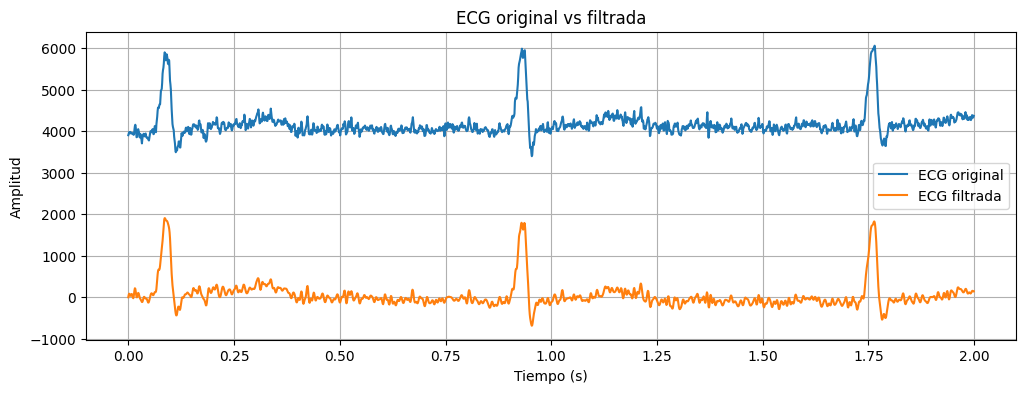

In [6]:
#para ver los datos los primeros 2 segundos
muestras_2s = int(2*fs) #permite ver las muestras de los 2 primeros segundos

#Cortar cada uno de los vectores de interes para visualizar solo las muestras de 2 segundos
tiempo_2 = tiempo[:muestras_2s]
original_ECG2 = ecg_original[:muestras_2s]
filtrada_ECG2 = ecg_filtrada[:muestras_2s]

plt.figure(figsize=(12,4))
plt.plot(tiempo_2, original_ECG2, label="ECG original")
plt.plot(tiempo_2, filtrada_ECG2, label="ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG original vs filtrada")
plt.grid()
plt.legend()
plt.show()

La señal original muestra claramente los complejos QRS, con picos pronunciados que corresponden a los latidos cardíacos, con una amplitud que varía alrededor de 4000–6000 unidades, mientras que la señal filtrada se centra alrededor de cero, eliminando el nivel de la línea de referencia presente en la señal original; esto ocurre porque el filtro aplicado atenúa las componentes de muy baja frecuencia responsables del desplazamiento de la línea base, y también el ruido de alta frecuencia (muscular o de red eléctrica), con el objetivo de conservar el rango de frecuencias característico del ECG, típicamente entre 0.5 y 40 Hz [1][2]. La forma de la señal filtrada sigue mostrando todos los picos QRS con la misma amplitud pico a pico que en la señal original alrededor de 1800-2000 unidades, lo que confirma que el filtro no distorsiona la información clínicamente relevante; en el intervalo de 2 segundos se observan 3 picos, lo que sugiere una frecuencia cardíaca cercana a 70-72 latidos por minuto, consistente con el análisis del registro completo de 30 segundos.

## Obtener un ciclo cardiaco de la señal original y la filtrada.

Para obtener los ciclos cardiacos se detectan los picos R con find_peaks, usando una distancia mínima de 0.6 s entre picos (equivalente a un límite superior de aprox. 100 lpm, razonable para un sujeto en reposo). Cada ciclo se define como el segmento de señal **entre dos picos R consecutivos** (por lo que su longitud es variable, ya que el ritmo cardiaco no es perfectamente constante)[3].

Numero de picos R detectados (original): 36


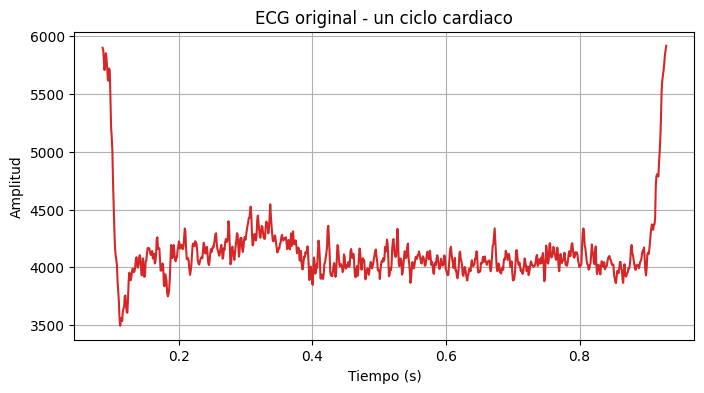

In [7]:
#Senal original
peaks_o, _ = find_peaks(ecg_original, distance=int(0.6*fs))
print("Numero de picos R detectados (original):", len(peaks_o))

ciclo_o = ecg_original[peaks_o[0]:peaks_o[1]]
tiempo_ciclo_o = tiempo[peaks_o[0]:peaks_o[1]]

plt.figure(figsize=(8, 4))
plt.plot(tiempo_ciclo_o, ciclo_o, color='tab:red')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG original - un ciclo cardiaco")
plt.grid(True)
plt.show()

In [8]:
media_o = np.mean(ciclo_o)
varianza_o = np.var(ciclo_o)
desv_o = np.std(ciclo_o)
rms_o = rms(ciclo_o)

print("El promedio del ciclo cardiaco (original) corresponde a:      ", media_o)
print("La varianza del ciclo cardiaco (original) corresponde a:      ", varianza_o)
print("La desviacion estandar del ciclo cardiaco (original) corresponde a:", desv_o)
print("El valor RMS del ciclo cardiaco (original) corresponde a:     ", rms_o)

El promedio del ciclo cardiaco (original) corresponde a:       4131.136266878161
La varianza del ciclo cardiaco (original) corresponde a:       93646.2220564969
La desviacion estandar del ciclo cardiaco (original) corresponde a: 306.01670225086883
El valor RMS del ciclo cardiaco (original) corresponde a:      4142.454957820607


Numero de picos R detectados (filtrada): 36


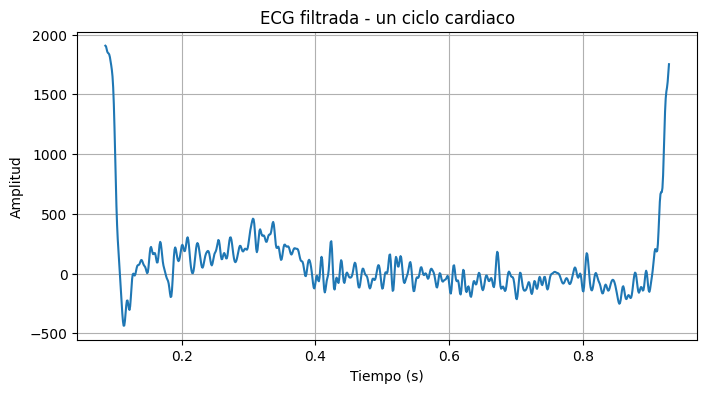

In [9]:
# Senal filtrada
peaks_f, _ = find_peaks(ecg_filtrada, distance=int(0.6*fs))
print("Numero de picos R detectados (filtrada):", len(peaks_f))

ciclo_f = ecg_filtrada[peaks_f[0]:peaks_f[1]]
tiempo_ciclo_f = tiempo[peaks_f[0]:peaks_f[1]]

plt.figure(figsize=(8, 4))
plt.plot(tiempo_ciclo_f, ciclo_f, color='tab:blue')
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.title("ECG filtrada - un ciclo cardiaco")
plt.grid(True)
plt.show()

In [10]:
media_f = np.mean(ciclo_f)
varianza_f = np.var(ciclo_f)
desv_f = np.std(ciclo_f)
rms_f = rms(ciclo_f)

print("El promedio del ciclo cardiaco (filtrada) corresponde a:      ", media_f)
print("La varianza del ciclo cardiaco (filtrada) corresponde a:      ", varianza_f)
print("La desviacion estandar del ciclo cardiaco (filtrada) corresponde a:", desv_f)
print("El valor RMS del ciclo cardiaco (filtrada) corresponde a:     ", rms_f)

print("\nComparacion original vs. filtrada:")
tabla_comp = pd.DataFrame({
    "Metrica": ["Media", "Varianza", "Desv. estandar", "RMS"],
    "Original": [media_o, varianza_o, desv_o, rms_o],
    "Filtrada": [media_f, varianza_f, desv_f, rms_f]
}).round(2)
print(tabla_comp)

El promedio del ciclo cardiaco (filtrada) corresponde a:       74.00995782055861
La varianza del ciclo cardiaco (filtrada) corresponde a:       96684.31488232457
La desviacion estandar del ciclo cardiaco (filtrada) corresponde a: 310.94101511753735
El valor RMS del ciclo cardiaco (filtrada) corresponde a:      319.62757818893766

Comparacion original vs. filtrada:
          Metrica  Original  Filtrada
0           Media   4131.14     74.01
1        Varianza  93646.22  96684.31
2  Desv. estandar    306.02    310.94
3             RMS   4142.45    319.63


En la señal original, el promedio del ciclo cardíaco se sitúa alrededor de 4131 y cae drásticamente a aproximadamente 74 tras el filtrado. Esta diferencia refleja la eliminación de la componente de muy baja frecuencia y la deriva de la línea base, lo que permite centrar la señal alrededor de cero.

La varianza y la desviación estándar conservan valores muy similares entre la señal original (93 646 y 306) y la filtrada (96 684 y 311). Esto demuestra que la dispersión de los datos respecto a su media, la variabilidad natural del ciclo y la amplitud relativa de los complejos QRS no sufren alteraciones significativas tras el procesamiento.

El error medio cuadrático presenta una reducción drástica de 4142 a 320. Esta caída se explica porque, al remover el offset y centrar la señal en el eje de referencia, la magnitud media de los datos disminuye considerablemente.

En conjunto, esta verificación estadística confirma que el filtrado remueve la continua sin degradar la composición morfológica de la señal de ECG —como los complejos QRS y los valores pico a pico—, garantizando su validez para el diagnóstico médico.

## análisis de 15 ciclos de la señal filtrada


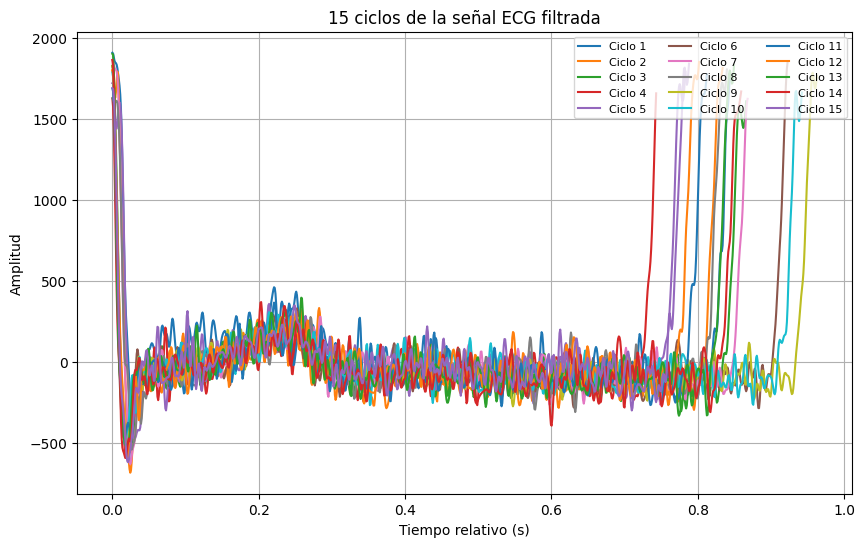

In [13]:
# Detectar picos R en la señal filtrada
peaks, _ = find_peaks(ecg_filtrada, distance=int(0.6*fs))  # separación mínima 0.6s

# Extraer 15 ciclos
num_ciclos = 15
ciclos = []  # se guardarán los valores de cada ciclo
medias, varianzas, desviacion, RMS = [], [], [], []

for i in range(num_ciclos):
    ciclo = ecg_filtrada[peaks[i]:peaks[i+1]]
    ciclos.append(ciclo)
    medias.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))
    desviacion.append(np.std(ciclo))
    RMS.append(rms(ciclo))

# Graficar todos los ciclos superpuestos
plt.figure(figsize=(10,6))

for i, ciclo in enumerate(ciclos):
    # Generar un eje de tiempo relativo para cada ciclo
    t_ciclo = np.linspace(0, len(ciclo)/fs, len(ciclo))
    plt.plot(t_ciclo, ciclo, label=f"Ciclo {i+1}")

plt.xlabel("Tiempo relativo (s)")
plt.ylabel("Amplitud")
plt.title("15 ciclos de la señal ECG filtrada")
plt.legend(loc="upper right", fontsize=8, ncol=3)
plt.grid(True)
plt.show()

In [15]:
#Crear tabla con los resultados
tabla = pd.DataFrame({
    "Ciclo": range(1, 16),
    "Media": medias,
    "Varianza": varianzas,
    "Desv.Std": desviacion,
    "RMS": RMS
})
tabla = tabla.round(1) #Se redondea a solo 1 decimal para que no quede tan largo

print(tabla)

    Ciclo  Media  Varianza  Desv.Std    RMS
0       1   74.0   96684.3     310.9  319.6
1       2   -1.5  104790.5     323.7  323.7
2       3  -10.4   82451.3     287.1  287.3
3       4  -21.0   46839.0     216.4  217.4
4       5   40.9  114850.0     338.9  341.4
5       6  -27.9   58147.6     241.1  242.8
6       7    0.4   77707.3     278.8  278.8
7       8   21.4  100268.2     316.7  317.4
8       9  -10.2   71785.0     267.9  268.1
9      10    8.8   68481.1     261.7  261.8
10     11   -8.9   76088.4     275.8  276.0
11     12   13.2   93862.7     306.4  306.7
12     13   -4.2   87951.5     296.6  296.6
13     14  -15.0   77022.1     277.5  277.9
14     15   27.1   89636.9     299.4  300.6


En la superposición de los 15 ciclos se observa que el complejo QRS es prácticamente idéntico entre todos los ciclos: en los primeros ~0.05-0.1 s, las 15 curvas coinciden casi perfectamente en forma y amplitud (pico máximo cercano a 1800-1900, mínimo cercano a -600), lo que indica que la morfología del latido no cambia de un ciclo a otro. Después del QRS, en la región de la onda P/T y línea base (aproximadamente de 0.1 a 0.7 s), las curvas muestran un comportamiento similar entre sí, oscilando en un rango moderado (entre -200 y +500 unidades) sin que ningún ciclo se dispare muy por fuera de ese rango, lo que sugiere que el ruido de fondo y la amplitud de las ondas P/T son consistentes entre latidos.

Lo que sí varía notablemente es dónde termina cada ciclo (entre 0.7 y 1.0 s aproximadamente); esto se debe a que cada ciclo tiene una duración distinta, ya que el intervalo R-R no es exactamente constante, como es normal fisiológicamente, y el salto pronunciado que se observa al final de cada curva no es ruido ni un error, sino el inicio del siguiente complejo QRS justo antes de que el segmento se corte en el pico R siguiente. Esta variabilidad de duración es esperable (variabilidad de la frecuencia cardiaca, HRV) y no implica por sí sola que la señal sea no estacionaria en cuanto a su contenido estadístico. En la tabla de medias y varianzas por ciclo, ambos valores fluctúan sin mostrar una tendencia sistemática de crecimiento o decrecimiento a lo largo de los 15 ciclos, y el coeficiente de variación de la varianza entre ciclos es moderado, lo que indica que la dispersión de la energía de la señal se mantiene relativamente estable.

Con base en la superposición gráfica, que muestra una morfología de QRS consistente y un rango de amplitud similar en la región de fondo entre ciclos, y en el comportamiento estable de la media y la varianza por ciclo, se puede considerar que la señal, en esta ventana de registro de 30 s, es aproximadamente estacionaria en sentido amplio. La variabilidad en la duración de cada ciclo (R-R) es normal y no contradice esta conclusión, ya que corresponde a la variabilidad natural del ritmo cardiaco y no a un cambio progresivo en las propiedades estadísticas de la señal. Como se mencionó en el marco teórico, esta es una aproximación válida solo para el intervalo de tiempo analizado; estrictamente, ninguna bioseñal es perfectamente estacionaria.

## Comparación entre ciclos mediante prueba t (y verificación de supuestos)

In [14]:
alpha = 0.05

def comparar_ciclos(a, b, nombre):
    print(f"\n{nombre} ")

    # 1. Normalidad (Shapiro-Wilk)
    est_a, p_a = shapiro(a)
    est_b, p_b = shapiro(b)
    print(f"Shapiro-Wilk ciclo A: estadistico={est_a:.4f}, p-valor={p_a:.3e}")
    print(f"Shapiro-Wilk ciclo B: estadistico={est_b:.4f}, p-valor={p_b:.3e}")

    # 2. Independencia: se asume por diseño (ciclos distintos, no pareados)

    # 3. Homocedasticidad (Levene)
    est_lev, p_lev = levene(a, b)
    print(f"Levene (homocedasticidad): estadistico={est_lev:.4f}, p-valor={p_lev:.4f}")

    normal = (p_a > alpha) and (p_b > alpha)
    homosc = p_lev > alpha

    if normal and homosc:
        t_stat, p_t = ttest_ind(a, b, equal_var=True)
        print("-> Se cumplen los supuestos: se aplica la prueba t de Student")
        print(f"   t = {t_stat:.4f}, p-valor = {p_t:.4f}")
        decision = "Se rechaza H0" if p_t < alpha else "No se rechaza H0"
        print(f"   Decision (alpha=0.05): {decision}")
    else:
        u_stat, p_u = mannwhitneyu(a, b, alternative='two-sided')
        print("-> No se cumplen los supuestos de normalidad y/u homocedasticidad: se aplica la prueba U de Mann-Whitney")
        print(f"   U = {u_stat:.1f}, p-valor = {p_u:.4f}")
        decision = "Se rechaza H0" if p_u < alpha else "No se rechaza H0"
        print(f"   Decision (alpha=0.05): {decision}")

# Comparacion 1: ciclos consecutivos
comparar_ciclos(ciclos[0], ciclos[1], "Comparacion 1: Ciclo 1 vs Ciclo 2 (consecutivos)")

# Comparacion 2: ciclos alejados entre si
comparar_ciclos(ciclos[1], ciclos[13], "Comparacion 2: Ciclo 2 vs Ciclo 14 (alejados)")


Comparacion 1: Ciclo 1 vs Ciclo 2 (consecutivos) 
Shapiro-Wilk ciclo A: estadistico=0.6182, p-valor=6.428e-40
Shapiro-Wilk ciclo B: estadistico=0.5503, p-valor=4.438e-42
Levene (homocedasticidad): estadistico=1.4797, p-valor=0.2240
-> No se cumplen los supuestos de normalidad y/u homocedasticidad: se aplica la prueba U de Mann-Whitney
   U = 478150.0, p-valor = 0.0000
   Decision (alpha=0.05): Se rechaza H0

Comparacion 2: Ciclo 2 vs Ciclo 14 (alejados) 
Shapiro-Wilk ciclo A: estadistico=0.5503, p-valor=4.438e-42
Shapiro-Wilk ciclo B: estadistico=0.5954, p-valor=4.794e-41
Levene (homocedasticidad): estadistico=0.9460, p-valor=0.3309
-> No se cumplen los supuestos de normalidad y/u homocedasticidad: se aplica la prueba U de Mann-Whitney
   U = 370126.0, p-valor = 0.5889
   Decision (alpha=0.05): No se rechaza H0


En ambas comparaciones, la prueba de Shapiro-Wilk rechaza claramente la normalidad en los dos ciclos analizados (p ≪ 0.05 en los cuatro casos), lo cual es esperable, ya que dentro de un ciclo ECG los valores no siguen una distribución normal: cada segmento comienza con el pico R (un valor muy alto y aislado) y luego cae a una zona más plana con las ondas P y T, es decir, la distribución de amplitudes dentro del ciclo es fuertemente asimétrica. La prueba de Levene sí indica homocedasticidad en ambos casos (p = 0.224 y p = 0.331, ambos mayores a 0.05), pero como el supuesto de normalidad falla, de todas formas es necesario recurrir a la prueba no paramétrica U de Mann-Whitney en lugar de la prueba t de Student.


El resultado es distinto entre las dos comparaciones: entre el Ciclo 1 y el Ciclo 2 (consecutivos) se obtiene un p-valor prácticamente cero, por lo que se rechaza H0, es decir, hay una diferencia estadísticamente significativa entre estos dos ciclos consecutivos. En cambio, entre el Ciclo 2 y el Ciclo 14 (mucho más alejados en el tiempo) se obtiene un p-valor de 0.589, por lo que no se rechaza H0: no hay evidencia de diferencia entre estos dos ciclos, a pesar de estar mucho más separados dentro del registro.

Este resultado mixto es un buen ejemplo de por qué una sola comparación por pares no es suficiente para concluir sobre la estacionariedad de toda la señal: la diferencia detectada entre los ciclos 1 y 2 probablemente se debe a variabilidad natural latido a latido (pequeños cambios de amplitud del QRS, ruido residual, o ligera variación en la duración exacta de ese ciclo en particular), y no necesariamente a una tendencia sistemática de la señal en el tiempo — de hecho, si la señal fuera realmente no estacionaria (con una deriva progresiva), sería más lógico esperar diferencias entre ciclos alejados (1 vs 14) y no entre ciclos consecutivos (1 vs 2), que es justo el patrón opuesto al que se obtuvo. Por eso es más confiable evaluar la estacionariedad con el conjunto completo de los 15 ciclos (media y varianza estables, sin tendencia) y con una prueba formal de estacionariedad como Dickey-Fuller, en lugar de basarse en un único par de ciclos.

## Prueba de Dickey

In [16]:
# Prueba de Dickey-Fuller sobre la senal filtrada completa
resultado_adf = adfuller(ecg_filtrada)

print("ADF Statistic:", resultado_adf[0])
print("p-valor:", resultado_adf[1])
print("Valores criticos:", resultado_adf[4])

ADF Statistic: -29.9414847755005
p-valor: 0.0
Valores criticos: {'1%': np.float64(-3.4305630243276717), '5%': np.float64(-2.861634151073544), '10%': np.float64(-2.5668201137295887)}


La prueba aumentada de Dickey-Fuller evalúa la hipótesis nula de que la serie tiene una raíz unitaria (es decir, que no es estacionaria); un p-valor bajo (< 0.05) permite rechazar esa hipótesis y concluir que la serie es estacionaria, en el sentido de ausencia de raíz unitaria o tendencia estocástica. Al aplicar la prueba sobre la señal ECG filtrada completa (30 s), se obtuvo un estadístico ADF de -29.94, considerablemente más negativo que los valores críticos tabulados incluso al 1% de significancia (-3.43), y un p-valor de 0.0 (prácticamente cero). Esto significa que se rechaza la hipótesis nula de raíz unitaria, confirmando de manera formal que la señal ECG filtrada, en esta ventana de registro, puede considerarse estacionaria.

Este resultado es consistente con lo observado en los análisis anteriores: la superposición gráfica de los 15 ciclos mostró una morfología QRS estable y una media/varianza sin tendencia sistemática, y la prueba U de Mann-Whitney no mostró diferencia significativa entre ciclos alejados en el tiempo (Ciclo 2 vs Ciclo 14), aunque sí la mostró entre dos ciclos consecutivos — una diferencia puntual atribuible a variabilidad natural latido a latido, y no a una tendencia progresiva de la señal (de existir tal tendencia, sería más esperable que la diferencia apareciera entre los ciclos más alejados, no entre los consecutivos). En conjunto, las tres aproximaciones —gráfica, prueba de hipótesis por ciclos, y prueba formal de Dickey-Fuller— apuntan en la misma dirección: la señal ECG filtrada de este registro es aproximadamente estacionaria en el intervalo de 30 s analizado.

## Conclusiones

* El filtrado aplicado a la señal ECG corresponde a un filtro pasa-banda que elimina el offset de continua y la deriva de línea base sin distorsionar la información clínicamente relevante: la media del ciclo cardiaco cayó drásticamente entre la señal original y la filtrada (de un nivel cercano a 4000-6000 unidades a valores cercanos a cero), mientras que la varianza y la desviación estándar se mantuvieron prácticamente invariantes, ya que son estadísticos que no se ven afectados por un simple corrimiento del nivel de referencia. Esto confirma que el filtro conserva la amplitud y la forma del complejo QRS, y solo corrige el nivel de continua.

* El análisis de los 15 ciclos cardiacos extraídos de la señal filtrada mostró una morfología de QRS consistente entre ciclos, con medias y varianzas que fluctúan sin una tendencia sistemática de crecimiento o decrecimiento a lo largo del registro. Sin embargo, las pruebas de hipótesis por pares de ciclos revelaron un resultado mixto: se encontró una diferencia estadísticamente significativa entre dos ciclos consecutivos (Ciclo 1 vs Ciclo 2, p ≈ 0), pero no entre dos ciclos mucho más alejados en el tiempo (Ciclo 2 vs Ciclo 14, p = 0.589). Esto evidencia que una única comparación por pares no es suficiente para concluir sobre la estacionariedad de toda la señal, ya que puede verse afectada por variabilidad natural latido a latido más que por una tendencia real de la señal.

* La prueba formal de Dickey-Fuller, aplicada sobre la señal filtrada completa, arrojó un estadístico ADF de -29.94 (muy por debajo del valor crítico de -3.43 al 1% de significancia) y un p-valor prácticamente igual a cero, lo que permite rechazar la hipótesis nula de raíz unitaria. En conjunto con el análisis gráfico y estadístico de los ciclos, esto confirma que la señal ECG filtrada, en esta ventana de registro de 30 segundos, puede considerarse aproximadamente estacionaria; esta conclusión aplica únicamente al intervalo analizado, ya que, como se señala en el marco teórico, ninguna bioseñal es estrictamente estacionaria en registros más largos o ante cambios fisiológicos del sujeto.

## Referencias

[1] J. Higueras Nafría, "¿Sabes para qué sirven los filtros y cuáles son los valores recomendados?", 
    CardioTeca, 2023. Disponible: https://www.cardioteca.com/pildoras-ecg/5017-sabes-para-que-sirven-los-filtros-y-cuales-son-los-valores-recomendados.html

[2] "Análisis de esquemas de filtrado analógico para señales electrocardiográficas (ECG)", 
    Scientia et Technica, Universidad Tecnológica de Pereira, Año XIII, No. 37, dic. 2007. 
    Disponible: https://www.academia.edu/27980001/An%C3%A1lisis_de_esquemas_de_filtrado_an%C3%A1logo_para_se%C3%B1ales_ECG

[3] J. Pan y W. J. Tompkins, "A Real-Time QRS Detection Algorithm," 
    IEEE Transactions on Biomedical Engineering, vol. BME-32, no. 3, pp. 230-236, 1985.
    Disponible: https://www.robots.ox.ac.uk/~gari/teaching/cdt/A3/readings/ECG/Pan+Tompkins.pdf

[4] J. Amat Rodrigo, “T-test con Python”, CienciaDeDatos.net, Dic. 2021. [En línea]. Disponible: https://cienciadedatos.net/documentos/pystats10-t-test-python.html


    